In [5]:
from pathlib import Path
import sys
import json

import torch
import numpy as np
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Notebook đang ở: Jupyter/evaluate
NOTEBOOK_DIR = Path.cwd()
# Thư mục Jupyter (cha của evaluate)
ROOT_DIR = NOTEBOOK_DIR.parent

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("ROOT_DIR (Jupyter):", ROOT_DIR)

# Thêm thư mục models vào sys.path để import
sys.path.append(str(ROOT_DIR / "models"))

from efficientnet_b0 import (
    build_model,
    create_dataloaders,
    IMAGENET_MEAN,
    IMAGENET_STD,
)

# Đường dẫn dataset (giống main.py)
DATA_DIR = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images")

# Thư mục chứa các run (Jupyter/runs)
RUNS_ROOT = ROOT_DIR / "runs"
RUN_PREFIX = "MTL_TGFOOD_01"

print("RUNS_ROOT:", RUNS_ROOT)


NOTEBOOK_DIR: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/evaluate
ROOT_DIR (Jupyter): /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter
RUNS_ROOT: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs


In [ ]:
# Cell 2 – Chọn run cần đánh giá + checkpoint
# Liệt kê các run tên bắt đầu bằng MTL_TGFOOD_
run_dirs = sorted(
    [d for d in RUNS_ROOT.iterdir() if d.is_dir() and d.name.startswith(RUN_PREFIX)]
)

for i, d in enumerate(run_dirs):
    print(f"[{i}] {d.name}")

# === CHỌN RUN Ở ĐÂY ===
# Ví dụ: chọn index cuối (run mới nhất)
RUN_IDX = len(run_dirs) - 1
RUN_DIR = run_dirs[RUN_IDX]

print("\n✅ Đang dùng run:", RUN_DIR.name)
CKPT_PATH = RUN_DIR / "checkpoints" / "mtl_effb0_best.pt"
METRICS_PATH = RUN_DIR / "metrics.csv"

print("Checkpoint :", CKPT_PATH)
print("Metrics CSV:", METRICS_PATH)


[0] MTL_TGFOOD_01

✅ Đang dùng run: MTL_TGFOOD_01
Checkpoint : /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/MTL_TGFOOD_01/checkpoints/mtl_effb0_best.pt
Metrics CSV: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/MTL_TGFOOD_01/metrics.csv


In [ ]:
# Cell 3 – Load checkpoint + rebuild model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load checkpoint
ckpt = torch.load(CKPT_PATH, map_location=device)

class_names = ckpt["class_names"]
num_classes = len(class_names)
print("Số lớp:", num_classes)
print("Một vài lớp đầu:", class_names[:10])

# Build model với đúng số lớp, rồi load state_dict
model = build_model(
    num_classes=num_classes,
    dropout=0.4,          # giống main.py
    pretrained=False,     # không cần preload ImageNet nữa
    freeze_backbone=False,
    device=device,
)

model.load_state_dict(ckpt["model_state"])
model.eval()

print("✅ Model loaded xong.")


Device: cuda
Số lớp: 33
Một vài lớp đầu: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi']
✅ torch.compile enabled
✅ Model loaded xong.


In [ ]:
# Cell 4 – Tạo dataloader (train/val/test)
loaders, class_names2, class_counts = create_dataloaders(
    DATA_DIR,
    img_size=224,
    batch_size=64,
    num_workers=8,
)

assert class_names2 == class_names, "class_names không khớp giữa ckpt và dataloader!"

train_loader = loaders["train"]
val_loader   = loaders["val"]
test_loader  = loaders["test"]

len(train_loader), len(val_loader), len(test_loader)


Found 33 classes: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo', 'banh_da_lon', 'banh_tieu', 'banh_trung_thu']
Class counts: [511, 588, 598, 823, 448, 982, 706, 501, 635, 1103, 483, 486, 595, 956, 1338, 716, 573, 934, 547, 623, 625, 627, 863, 742, 655, 780, 684, 555, 607, 580, 580, 521, 542]


(352, 55, 52)

In [9]:
# Cell 5 – Hàm evaluate 1 loader (acc + y_true/y_pred)
def evaluate_loader(loader, model, device, desc="Eval"):
    model.eval()
    n_samples = 0
    correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, dynamic_ncols=True)
        for imgs, labels in pbar:
            imgs = imgs.to(device, non_blocking=True).to(memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device.type):
                logits = model(imgs)

            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            n_samples += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

            pbar.set_postfix(acc=correct / n_samples)

    acc = correct / n_samples
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return acc, all_labels, all_preds


In [10]:
# Cell 6 – Đánh giá trên val & test
val_acc, val_y_true, val_y_pred = evaluate_loader(val_loader, model, device, desc="Val")
print(f"\n📊 Val accuracy: {val_acc:.4f}")

test_acc, test_y_true, test_y_pred = evaluate_loader(test_loader, model, device, desc="Test")
print(f"\n📊 Test accuracy: {test_acc:.4f}")


Val:   0%|          | 0/55 [00:00<?, ?it/s]

W1118 20:35:05.807000 473958 torch/_inductor/utils.py:1613] [0/0] Not enough SMs to use max_autotune_gemm mode



📊 Val accuracy: 0.8846


Test:   0%|          | 0/52 [00:00<?, ?it/s]


📊 Test accuracy: 0.8730


=== Classification report (TEST) ===
                  precision    recall  f1-score   support

        Banh beo      0.860     0.920     0.889       100
    Banh bot loc      0.856     0.830     0.843       100
        Banh can      0.878     0.860     0.869       100
       Banh canh      0.771     0.740     0.755       100
      Banh chung      0.891     0.900     0.896       100
       Banh cuon      0.817     0.850     0.833       100
        Banh duc      0.791     0.720     0.754       100
        Banh gio      0.873     0.890     0.881       100
       Banh khot      0.899     0.890     0.894       100
         Banh mi      0.894     0.930     0.912       100
        Banh pia      0.947     0.890     0.918       100
        Banh tet      0.848     0.840     0.844       100
Banh trang nuong      0.832     0.940     0.883       100
        Banh xeo      0.895     0.850     0.872       100
      Bun bo Hue      0.745     0.790     0.767       100
 Bun dau mam tom      0.980     1.

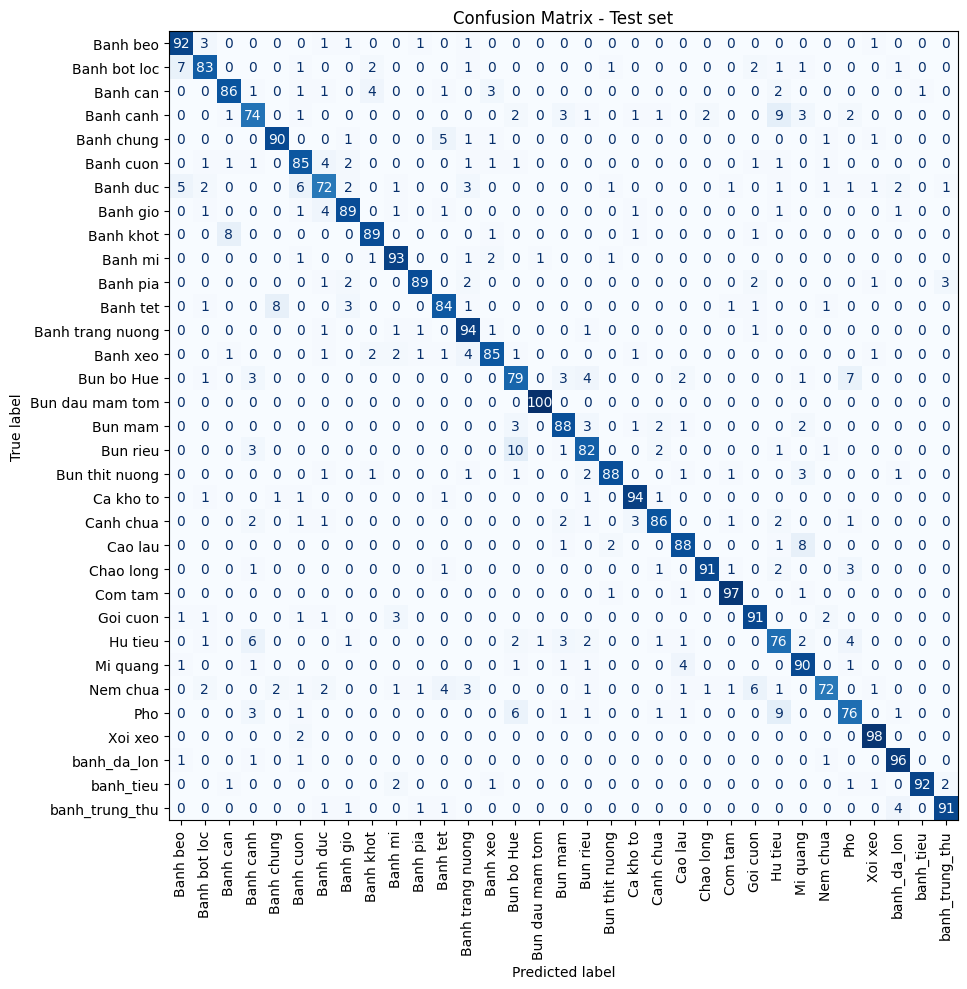

In [11]:
#Cell 7 – Classification report + Confusion matrix (val hoặc test)
from sklearn.metrics import ConfusionMatrixDisplay

print("=== Classification report (TEST) ===")
print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(test_y_true, test_y_pred, labels=range(num_classes))

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=False)
ax.set_title("Confusion Matrix - Test set")
plt.tight_layout()
plt.show()


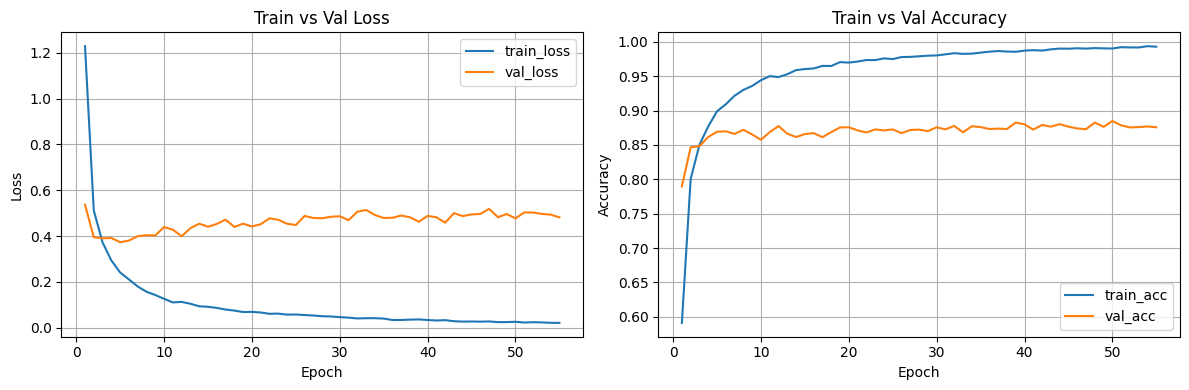

In [12]:
#Cell 8 – Vẽ lại loss/accuracy theo epoch từ metrics.csv
metrics = pd.read_csv(METRICS_PATH)
metrics.head()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(metrics["epoch"], metrics["train_loss"], label="train_loss")
axes[0].plot(metrics["epoch"], metrics["val_loss"],   label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Val Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(metrics["epoch"], metrics["train_acc"], label="train_acc")
axes[1].plot(metrics["epoch"], metrics["val_acc"],   label="val_acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train vs Val Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
